# Telecom Customer Churn — Supervised Classification Guide

This notebook demonstrates a **beginner-friendly machine learning workflow** using the dataset:

**TelecomCustomerChurn.csv**

Goal:

Predict whether a **customer will churn (leave the service)**.

Target column:

`Churn`

Steps covered:

1. Load dataset
2. Exploratory Data Analysis (EDA) with Seaborn
3. Data cleaning
4. Feature encoding
5. Train/test split
6. Train classification models one by one
7. Evaluate models
8. Compare results

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

## Load Dataset

In [2]:
churn = pd.read_csv("../datasets/TelecomCustomerChurn.csv")

churn.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [3]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Exploratory Data Analysis (EDA)

### Churn Distribution

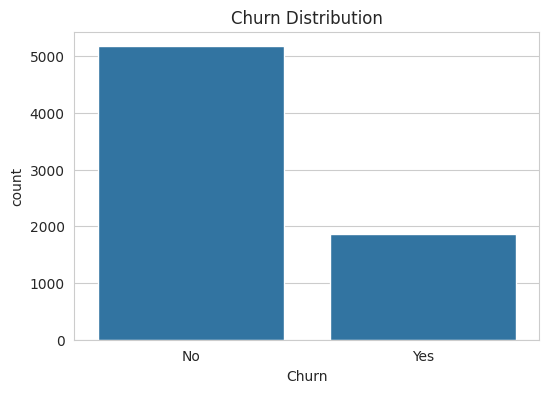

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=churn)
plt.title("Churn Distribution")
plt.show()

### Tenure Distribution

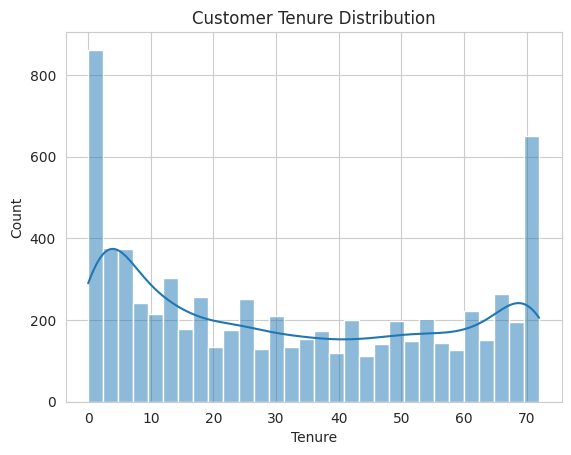

In [5]:
sns.histplot(churn["Tenure"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

### Monthly Charges Distribution

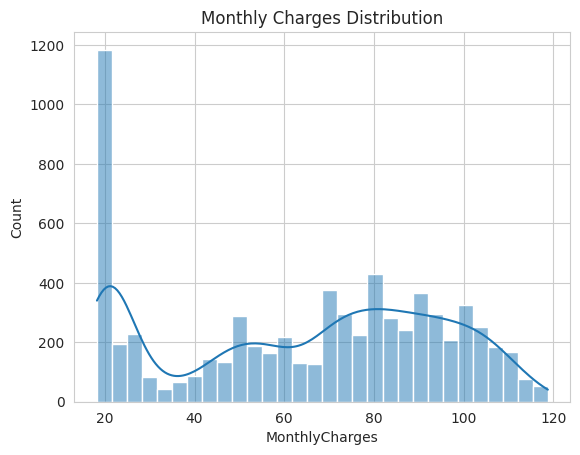

In [6]:
sns.histplot(churn["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

### Monthly Charges vs Churn

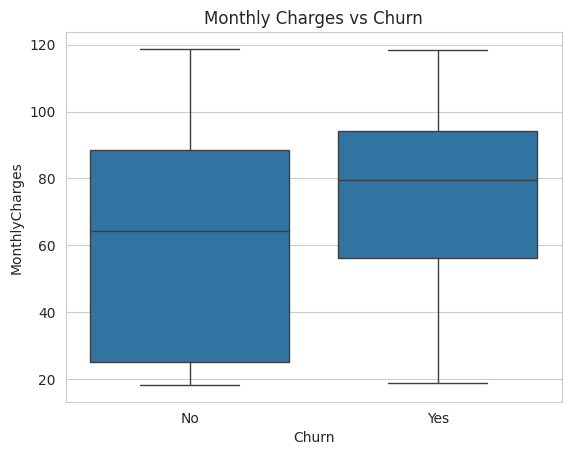

In [7]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=churn)
plt.title("Monthly Charges vs Churn")
plt.show()

### Tenure vs Churn

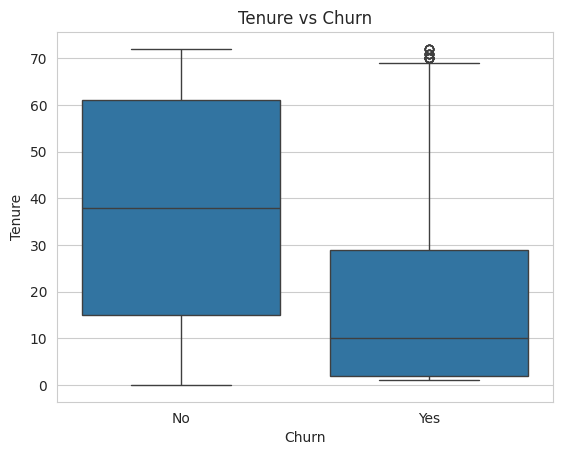

In [8]:
sns.boxplot(x="Churn", y="Tenure", data=churn)
plt.title("Tenure vs Churn")
plt.show()

### Correlation Heatmap

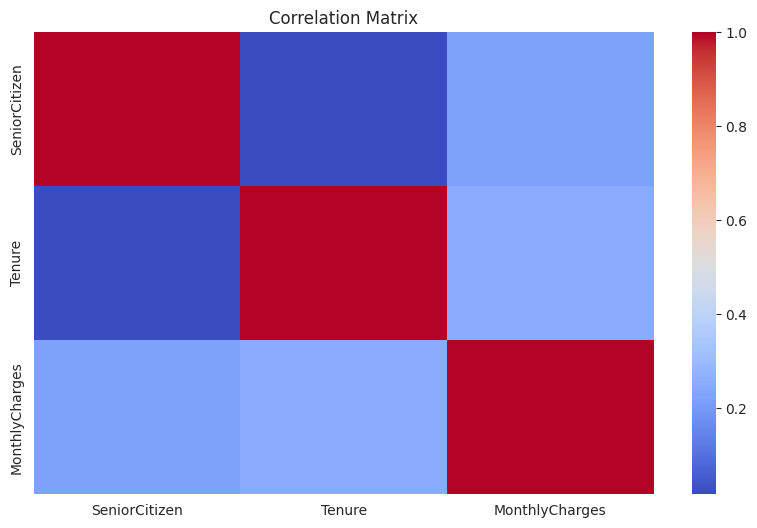

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(churn.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Data Cleaning

In [10]:
churn["TotalCharges"] = pd.to_numeric(churn["TotalCharges"], errors="coerce")

churn["TotalCharges"] = churn["TotalCharges"].fillna(churn["TotalCharges"].median())

churn = churn.drop("customerID", axis=1)

## Convert Target Variable

In [11]:
churn["Churn"] = churn["Churn"].map({"Yes":1,"No":0})

## Encode Categorical Variables

In [12]:
churn_encoded = pd.get_dummies(churn, drop_first=True)

## Train/Test Split

In [13]:
X = churn_encoded.drop("Churn", axis=1)
y = churn_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_preds)

log_acc

/opt/envs/ds/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8190205819730305

## Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_preds)

tree_acc

0.7217885024840313

## Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

rf_acc

0.7863733144073811

## Gradient Boosting

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_preds)

gb_acc

0.8168914123491838

## K-Nearest Neighbors

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)

knn_acc

0.7785663591199432

## Support Vector Machine

In [19]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_preds)

svm_acc

0.7352732434350603

## Compare Model Performance

In [20]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "SVM"
    ],
    "Accuracy":[
        log_acc,
        tree_acc,
        rf_acc,
        gb_acc,
        knn_acc,
        svm_acc
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.819021
3,Gradient Boosting,0.816891
2,Random Forest,0.786373
4,KNN,0.778566
5,SVM,0.735273
1,Decision Tree,0.721789


# Conclusion

This notebook demonstrated:

1. Data exploration with Seaborn
2. Data cleaning and preprocessing
3. Training multiple classification models
4. Evaluating and comparing models

Common strong models for churn prediction:

- Random Forest
- Gradient Boosting
- Logistic Regression

# SMOTE

In [21]:
# !pip install -U imbalanced-learn


In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Load dataset
churn = pd.read_csv("../datasets/TelecomCustomerChurn.csv")

# Drop ID column if present
if "customerID" in churn.columns:
    churn = churn.drop("customerID", axis=1)

# Convert TotalCharges if needed
if "TotalCharges" in churn.columns:
    churn["TotalCharges"] = pd.to_numeric(churn["TotalCharges"], errors="coerce")

# Target and features
X = churn.drop("Churn", axis=1)
y = churn["Churn"].map({"No": 0, "Yes": 1})

# Identify column types
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

# Full pipeline with SMOTE
pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Hyperparameter space
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

# Randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring="accuracy",
    n_jobs=1,
    verbose=2,
    random_state=42
)

# Train model
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
print("Best Parameters:", random_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 2 folds for each of 5 candidates, totalling 10 fits


[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=30, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=500; total time=   5.5s
[CV] END model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=500; total time=   5.9s
[CV] END model__max_depth=10, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=10, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__m

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7934705464868701
Precision: 0.6182336182336182
Recall: 0.5802139037433155
F1 Score: 0.5986206896551725


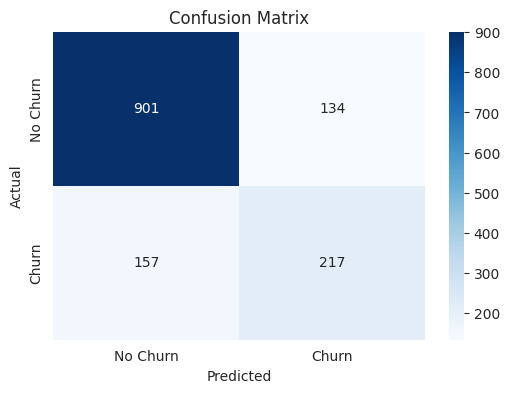

In [24]:
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
target_data = [0,0,0,0,0,0,0,0,0,1]

predictions = [0,0,0,0,0,0,0,0,0,0]

print(classification_report(target_data, predictions))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10



/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
target_data = [0,0,0,0,0,1,1,1,1,1]

predictions = [0,0,0,0,0,0,0,0,0,0]

print(classification_report(target_data, predictions))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         5
           1       0.00      0.00      0.00         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10



/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/envs/ds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
